<a href="https://colab.research.google.com/github/hohohoo07/Advanced_software_Lab./blob/main/%EC%8B%AC%EC%A0%84%EC%8B%A45%EC%A3%BC%EC%B0%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**실습: 임계값을 바꾸면 무엇이 달라질까 (p.9)**

--- T=80 결과 ---


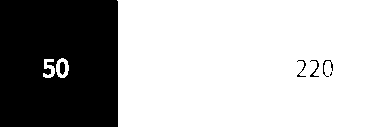

--- T=180 결과 ---


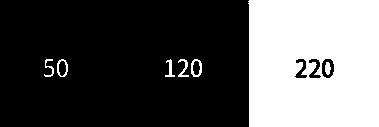

--- T=230 결과 ---


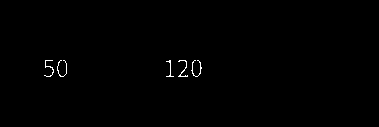

In [7]:
import cv2

img = cv2.imread('smaple.png', 0)
_, a = cv2.threshold(img, 80, 255, cv2.THRESH_BINARY)
_, b = cv2.threshold(img, 180, 255, cv2.THRESH_BINARY)
_, c = cv2.threshold(img, 230, 255, cv2.THRESH_BINARY)

# white_pixels_a = cv2.countNonZero(a)
# white_pixels_b = cv2.countNonZero(b)

# print(f"T=80일 때 흰색 픽셀 수: {white_pixels_a}")
# print(f"T=180일 때 흰색 픽셀 수: {white_pixels_b}")

from google.colab.patches import cv2_imshow

# 4. 결과 시각화
print("--- T=80 결과 ---")
cv2_imshow(a)

print("--- T=180 결과 ---")
cv2_imshow(b)

print("--- T=230 결과 ---")
cv2_imshow(c)

**고정 임계값 실습: 세 결과 비교 (p.13)**

--- T=80 결과 ---


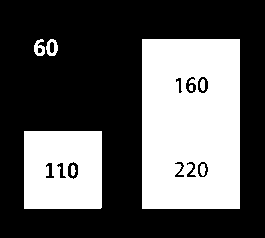

--- T=130 결과 ---


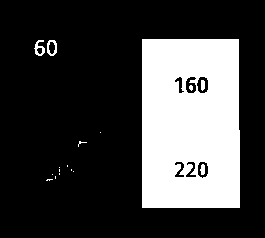

--- T=180 결과 ---


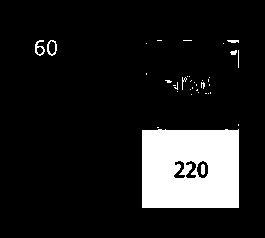

In [12]:
import cv2

img = cv2.imread('sample2.png', 0)
_, a = cv2.threshold(img, 80, 255, cv2.THRESH_BINARY)
_, b = cv2.threshold(img, 130, 255, cv2.THRESH_BINARY)
_, c = cv2.threshold(img, 180, 255, cv2.THRESH_BINARY)

from google.colab.patches import cv2_imshow

# 4. 결과 시각화
print("--- T=80 결과 ---")
cv2_imshow(a)

print("--- T=130 결과 ---")
cv2_imshow(b)

print("--- T=180 결과 ---")
cv2_imshow(c)


**실습: OpenCV에서 오츠 임계값 적용 (p.16)**

130.0


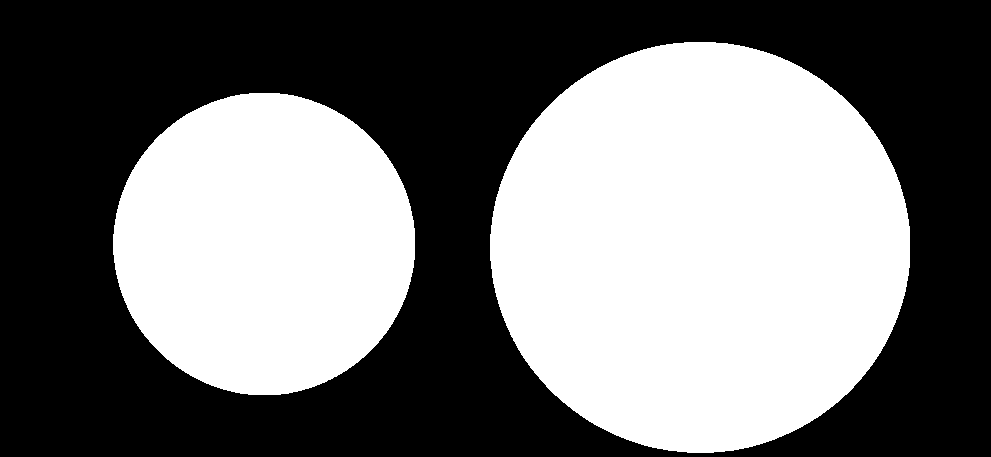

In [17]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread('sample3.png', cv2.IMREAD_GRAYSCALE)
t_otsu, mask = cv2.threshold(img, 0, 255,
cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print(t_otsu)

# 결과 사진 출력
cv2_imshow(mask)


**실습: OpenCV로 열림과 닫힘 적용 (p.26)**

=== 원본 마스크 (입력 mask) ===


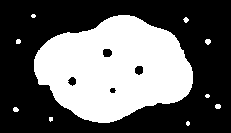


=== 열림 결과 (opened: 흰 잡음 제거) ===


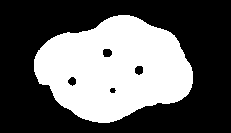


=== 닫힘 결과 (closed: 검은 구멍 메우기) ===


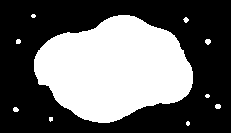

In [21]:
import cv2
from google.colab.patches import cv2_imshow

# 1. 캡처한 마스크 이미지를 그레이스케일로 읽기
# (이진 마스크이므로 단일 채널로 읽어옵니다)
mask = cv2.imread('sample4.png', cv2.IMREAD_GRAYSCALE)

if mask is None:
    print("경고: 'sample4.png' 파일을 찾을 수 없습니다. Colab 왼쪽 파일 탭에 업로드되었는지 확인하세요.")
else:
    # 캡처 이미지에 회색조가 섞여 있을 수 있으므로 확실한 이진 영상(0과 255)으로 정제
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # 2. 5x5 타원형 구조 요소(커널) 생성
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))

    # 3. 열림과 닫힘 연산 적용
    # 열림(Opening): 침식 후 팽창 -> 배경의 작은 흰 잡음 제거
    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # 닫힘(Closing): 팽창 후 침식 -> 대상 내부의 작은 검은 구멍 메우기
    closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # 4. 결과 출력
    print("=== 원본 마스크 (입력 mask) ===")
    cv2_imshow(mask)

    print("\n=== 열림 결과 (opened: 흰 잡음 제거) ===")
    cv2_imshow(opened)

    print("\n=== 닫힘 결과 (closed: 검은 구멍 메우기) ===")
    cv2_imshow(closed)